<a href="https://colab.research.google.com/github/shazam-25/retail-shelf-void-detection/blob/main/FedAvg_vs_FedAWA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<h2><b>FEDERATED LEARNING</b><h2>

<h4><b>Objective</b></h4>
<p>
The objective of this assignment is to implement and analyze advanced Federated Learning (FL) frameworks that address data heterogeneity, unstable convergence, and communication constraints. Students will work with Adaptive Weight Aggregation (FedAWA)</p>
<h4><b>Problem Statement</b></h4>
<p>Traditional Federated Learning methods such as FedAvg assign aggregation weights solely based on local dataset size, which often leads to unstable convergence under Non-IID data distributions. In mobile and decentralized environments, limited communication opportunities further degrade learning performance. This assignment explores adaptive aggregation as solutions to these challenges. </p>

In [ ]:
!pip install torchinfo
!pip install early_stopping_pytorch

In [ ]:
# ==========================
# Libraries
# ==========================
import cv2
import numpy as np
import pandas as pd
import os
import copy
import random

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
from early_stopping_pytorch import EarlyStopping

In [ ]:
# --- CONFIGURATION ---
NUM_CLIENTS = 10
NUM_ROUNDS = 30
LOCAL_EPOCHS = 3
BATCH_SIZE = 32
LEARNING_RATE = 0.01
PATIENCE = 10

##<h4><b>Retail Shelf Void Detection</h4></b>

Dataset: [Retail Shelf Void Detection Dataset - Kaggle](https://www.kaggle.com/datasets/aminefaris/retail-shelf-void-detection-dataset?resource=download)

Objective: Design a model to support the development and evaluation of object detection models focued on identifying voids (empty spaces) on retail shelves.

Benefits: Detecting these voids is critical for automating stock monitoing and improving shelf availability in retail environments.



##<h4><b> Load Data and Create Datasets</b></h4>

1.   Data Preprocessing
2.   Balanced Dataset Creation
3.   Split Dataset (Train and Validation)
4.   Validation dataset creation
5.   Test dataset creation



In [ ]:
# ==========================
# Load Dataset from Drive
# ==========================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- CONFIGURATION ---
TRAIN_IMAGE_DIR = '/content/drive/MyDrive/Colab Notebooks/DISTRIBUTED ML ASSIGN/ASSIGN2/DATASET_v1.0_NOT_DISTRIBUTED/raw_train/images'  # Folder with .jpg files
TRAIN_LABEL_DIR = '/content/drive/MyDrive/Colab Notebooks/DISTRIBUTED ML ASSIGN/ASSIGN2/DATASET_v1.0_NOT_DISTRIBUTED/raw_train/labels'  # Folder with .txt files
TRAIN_PROCESS_DIR = '/content/drive/MyDrive/Colab Notebooks/DISTRIBUTED ML ASSIGN/ASSIGN2/DATASET_v1.0_NOT_DISTRIBUTED/processed_train'

TEST_IMAGE_DIR = '/content/drive/MyDrive/Colab Notebooks/DISTRIBUTED ML ASSIGN/ASSIGN2/DATASET_v1.0_NOT_DISTRIBUTED/raw_test/images'
TEST_LABEL_DIR = '/content/drive/MyDrive/Colab Notebooks/DISTRIBUTED ML ASSIGN/ASSIGN2/DATASET_v1.0_NOT_DISTRIBUTED/raw_test/labels'
TEST_PROCESS_DIR = '/content/drive/MyDrive/Colab Notebooks/DISTRIBUTED ML ASSIGN/ASSIGN2/DATASET_v1.0_NOT_DISTRIBUTED/processed_test'

PATCH_SIZE = (64, 64)

# Make directory to store processed train data
os.makedirs(f"{TRAIN_PROCESS_DIR}/void", exist_ok=True)
os.makedirs(f"{TRAIN_PROCESS_DIR}/product", exist_ok=True)

# Make directory to store processed test data
os.makedirs(f"{TEST_PROCESS_DIR}/void", exist_ok=True)
os.makedirs(f"{TEST_PROCESS_DIR}/product", exist_ok=True)

# ==========================
# YOLO to Pixel Format
# ==========================
def yolo_to_pixel(yolo_coords, img_w, img_h):
  """
  Converts normalized YOLO (center_x, center_y, w, h)
  to pixel coordinates (xmin, ymin, xmax, ymax).
  """
  cx, cy, w, h = yolo_coords
  xmin = int((cx - w / 2) * img_w)
  ymin = int((cy - h / 2) * img_h)
  xmax = int((cx + w / 2) * img_w)
  ymax = int((cy + h / 2) * img_h)
  return xmin, ymin, xmax, ymax

# ==========================
# No Overlap between
# Void and Product Boxes
# ==========================
def is_overlapping(new_box, void_boxes):
  """
  Checks if a random product box overlaps with
  any known void boxes.
  """
  nx1, ny1, nx2, ny2 = new_box
  for (vx1, vy1, vx2, vy2) in void_boxes:
    # Check if boxes intersect
    if not (nx2 < vx1 or nx1 > vx2 or ny2 < vy1 or ny1 > vy2):
      return True
  return False

# ==========================
# Separate Void and Product
# ==========================
def void_product_split(image_dir, label_dir, process_dir):
  image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))]

  for img_name in image_files:
    # 1. Load Image
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    if img is None: continue
    img_h, img_w, _ = img.shape

    # 2. Find the matching label file
    label_path = os.path.join(label_dir, img_name.rsplit('.', 1)[0] + '.txt')
    if not os.path.exists(label_path): continue

    void_boxes = []

    # 3. Extract Voids
    with open(label_path, 'r') as f:
      lines = f.readlines()
      for i, line in enumerate(lines):
        data = list(map(float, line.split()))
        # Class 0 is usually the void
        coords = data[1:]
        xmin, ymin, xmax, ymax = yolo_to_pixel(coords, img_w, img_h)

        # Ensure coordinates are within image bounds
        xmin, ymin = max(0, xmin), max(0, ymin)
        xmax, ymax = min(img_w, xmax), min(img_h, ymax)

        void_boxes.append((xmin, ymin, xmax, ymax))

        crop = img[ymin:ymax, xmin:xmax]
        if crop.size == 0: continue

        resized = cv2.resize(crop, PATCH_SIZE)
        cv2.imwrite(f"{process_dir}/void/{img_name}_v{i}.jpg", resized)

    # 4. Extract "Product" patches (Random Sampling)
    # Create non-void patches for the CNN to learn the "Full" shelf
    attempts = 0
    sampled = 0
    while sampled < len(void_boxes) and attempts < 100:
      attempts += 1
      rx = np.random.randint(0, img_w - PATCH_SIZE[0])
      ry = np.random.randint(0, img_h - PATCH_SIZE[1])
      new_box = (rx, ry, rx + 64, ry + 64)

      if not is_overlapping(new_box, void_boxes):
        product_crop = img[ry:ry+64, rx:rx+64]
        cv2.imwrite(f"{process_dir}/product/{img_name}_p{sampled}.jpg", product_crop)
        sampled += 1

# Perform preprocessing for Train set
print("Preprocessing Train Set...")
# void_product_split(TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR, TRAIN_PROCESS_DIR)
print("Preprocessing complete. Data organized for Federated Learning split.")
print("\nPreprocessing Test Set...")
# void_product_split(TEST_IMAGE_DIR, TEST_LABEL_DIR, TEST_PROCESS_DIR)
print("Preprocessing complete. Data organized for Federated Learning split.")

Mounted at /content/drive
Preprocessing Train Set...
Preprocessing complete. Data organized for Federated Learning split.

Preprocessing Test Set...
Preprocessing complete. Data organized for Federated Learning split.


In [ ]:
# ==========================
# Create Balanced Dataset
# ==========================
# --- CONFIGURATION ---
# DATA_DIR = PREPROCESS_DIR --> Folder containing 'void' and 'patch' subfolders
IMAGE_SIZE = 64 # Should match the patch size

def load_data(data_dir):
  X = []  # Store image paths
  y = []  # labels 0:void, 1:product

  # Map folder names to integer labels
  categories = {'void': 0, 'product': 1}

  for category, label in categories.items():
    category_path = os.path.join(data_dir, category)

    # Iterate through every image in the folder
    for img_name in os.listdir(category_path):
      img_path = os.path.join(category_path, img_name)

      # Read image and convert from BGR (OpenCV default) to RGB
      img = cv2.imread(img_path)
      if img is None: continue
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      # Add to list
      X.append(img)
      y.append(label)

  # Convert lists to NumPy arrays
  X = np.array(X, dtype='float32')
  y = np.array(y, dtype='int32')

  # NORMALIZATION: Scale pixels from [0, 255] tp [0, 1]
  X = X / 255.0
  # Convert NumPy (B, H, W, C) to PyTorch (B, C, H, W) --> Remove
  # X = torch.tensor(X).permute(0, 3, 1, 2) ---> Remove

  return X, y

# Execute loading
X_train, y_train = load_data(TRAIN_PROCESS_DIR)
X_test, y_test = load_data(TEST_PROCESS_DIR)

# Get Dataset
print(f"Dataset Loaded Successfully!")
# Perform Data Validation
print(f"Numerical Data Validation (Train Set):")
print(f"Total Sample: {len(X_train)}")
print(f"Shape of X: {X_train.shape}") # (Total, H, W, C)
print(f"Shape of y: {y_train.shape}") # (Total,)

print(f"\nNumerical Data Validation (Test Set):")
print(f"Total Sample: {len(X_test)}")
print(f"Shape of X: {X_test.shape}")
print(f"Shape of y: {y_test.shape}") # (Total,)

Dataset Loaded Successfully!
Numerical Data Validation (Train Set):
Total Sample: 4684
Shape of X: (4684, 64, 64, 3)
Shape of y: (4684,)

Numerical Data Validation (Test Set):
Total Sample: 296
Shape of X: (296, 64, 64, 3)
Shape of y: (296,)


In [ ]:
# ==========================
# Split Dataset
# Train and Validation Set
# ==========================
# Split your full dataset: 80% for clients (train), 20% for the server (test)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
# ==========================
# Create Validation Loader
# ==========================
# batch_X need to be (Batch, 3, 64, 64)
X_val = torch.tensor(X_val).permute(0, 3, 1, 2)
y_val = torch.tensor(y_val).float().unsqueeze(1)
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# Sample size
print(f"Validation Set Sample Size: {len(val_dataset)}")

Validation Set Sample Size: 937


In [ ]:
# ==========================
# Create Test Loader
# ==========================
# batch_X need to be (Batch, 3, 64, 64)
X_test = torch.tensor(X_test).permute(0, 3, 1, 2)
y_test = torch.tensor(y_test).float().unsqueeze(1)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# Sample size
print(f"Test Set Sample Size: {len(test_dataset)}")

Test Set Sample Size: 296


##<h4><b>Model Design</b></h4>

1.   Model Architecture
2.   Model Evaluation Function
3.   Model Training Loop



In [ ]:
# ==========================
# Define Model Architecture
# ==========================
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    # Layer 1: Convolutional layer
    # Input: 3 channels (RGB), Output: 16 filters, Kernel size: 3x3
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces 64x64 to 32x32

    # Layer 2: Convolutional layer
    # Input: 16 filters, Output: 32 filters, Kernel size: 3x3
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
    # Pooling again reduces 32x32 to 16x16

    # Layer 3: Fully Connected (Dense) layers
    # 32 filters * 16px * 16px = 8192 flattened features
    self.fc1 = nn.Linear(32 * 16 * 16, 128)
    self.fc2 = nn.Linear(128, 1)  # Output 1 for binary classification (Void vs Product)

    self.dropout = nn.Dropout(0.2)

  def forward(self, x):
    # Apply Conv -> ReLU -> Pool
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))

    # Flatten the image for the dense layers
    x = x.view(-1, 32 * 16 * 16)

    x = F.relu(self.fc1(x))
    x = self.dropout(x)

    # Sigmoid activation for binary probability output
    x = torch.sigmoid(self.fc2(x))
    return x

# Initialize the model
summary(CNN(), (3, 64, 64)) # Input --> (3, 64, 64)

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 1]                    --
├─Conv2d: 1-1                            [16, 64, 64]              448
├─MaxPool2d: 1-2                         [16, 32, 32]              --
├─Conv2d: 1-3                            [32, 32, 32]              4,640
├─MaxPool2d: 1-4                         [32, 16, 16]              --
├─Linear: 1-5                            [1, 128]                  1,048,704
├─Dropout: 1-6                           [1, 128]                  --
├─Linear: 1-7                            [1, 1]                    129
Total params: 1,053,921
Trainable params: 1,053,921
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.26
Input size (MB): 0.05
Forward/backward pass size (MB): 0.79
Params size (MB): 4.22
Estimated Total Size (MB): 5.05

In [ ]:
# ==========================
# Helper Function: Model Evaluation
# ==========================
def evaluate_model(model, test_loader):
  model.eval()  # Set model to evaluation mode
  correct = 0
  total = 0
  total_loss = 0.0 # Initialize total loss
  criterion = nn.BCELoss() # Define criterion once

  # No Gradient calculation during evaluation
  with torch.no_grad():
    for batch_x, batch_y in test_loader:
      output = model(batch_x)
      loss = criterion(output, batch_y) # Calculate loss for current batch
      total_loss += loss.item() * batch_y.size(0) # Accumulate weighted loss

      # Since we use Sigmoid, outputs are probabilities (0.0 to 1.0)
      # Threshold at 0.5: >0.5 is Class 1 (Product), <=0.5 is Class 0 (Void)
      predicted = (output > 0.5).float()

      total += batch_y.size(0)
      correct += (predicted == batch_y).sum().item()

  accuracy = 100 * correct / total
  average_loss = total_loss / total # Calculate average loss over all samples
  return accuracy, average_loss # Return both values

In [ ]:
# ==========================
# Helper Function: Local Training
# ==========================
def local_train(model, train_loader, epochs=LOCAL_EPOCHS, lr=LEARNING_RATE):
  model.train()
  optimizer = optim.Adam(model.parameters(), lr=lr)
  criterion = torch.nn.BCELoss()  # Initialize loss function
  for epoch in range(epochs):
    for batch_x, batch_y in train_loader:
      optimizer.zero_grad()
      output = model(batch_x)
      loss = criterion(output, batch_y)
      loss.backward()
      optimizer.step()
  return model.state_dict()

##<h4><b>Part A: Baseline Federated Learning (FedAvg) </b></h4>

A1. Implement FedAvg with 10 clients using a Non-IID data split (Dirichlet α = 0.5). Train a simple CNN or Logistic Regression model for 50 communication rounds.

A2. Plot global test accuracy versus communication rounds.

In [ ]:
# ==========================
# Helper Function: Non-IID Split
# ==========================
def dirichlet_split(data, labels, n_clients, alpha=0.5):
  n_classes = len(np.unique(labels))
  # Create a matrix of shape (10 clients, 2 classes)
  label_distribution = np.random.dirichlet([alpha] * n_clients, n_classes)

  client_indices = [[] for _ in range(n_clients)]
  for c in range(n_classes):
    idx_k = np.where(labels == c)[0]
    np.random.shuffle(idx_k)

    # Distribute class indices to clients based on Dirichlet distribution
    proportions = label_distribution[c]
    split_points = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]
    idx_splits = np.split(idx_k, split_points)

    for i in range(n_clients):
      client_indices[i].extend(idx_splits[i])

  return client_indices

In [ ]:
# ==========================
# Non-IID Training Data Split
# Dirichlet (alpha=0.5)
# ==========================
client_indices = dirichlet_split(X_train, y_train, n_clients=NUM_CLIENTS, alpha=0.5)

# Label Distribution in each client
for id, indices in enumerate(client_indices):
  print(f"Client {id + 1}: {len(indices)} samples")

# Prepare Data for Clients
client_loaders = []
for i in range(NUM_CLIENTS):
  # Get indices for this specific store
  idx = client_indices[i]

  # Convert to PyTorch tensors
  x_tensor = torch.tensor(X_train[idx]).permute(0, 3, 1, 2)
  y_tensor = torch.tensor(y_train[idx]).float().unsqueeze(1)

  dataset = TensorDataset(x_tensor, y_tensor)
  client_loaders.append(DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True))

print(f"\nDataset Successfully distributed among {NUM_CLIENTS} clients.")

Client 1: 208 samples
Client 2: 238 samples
Client 3: 268 samples
Client 4: 371 samples
Client 5: 873 samples
Client 6: 564 samples
Client 7: 209 samples
Client 8: 272 samples
Client 9: 420 samples
Client 10: 324 samples

Dataset Successfully distributed among 10 clients.


In [ ]:
# ==========================
# FEDERATED TRAINING LOOP
# A1: FEDAVG BASELINE
# ==========================
def run_fedavg(global_model, client_loaders, test_loader=val_loader, rounds=NUM_ROUNDS):
  acc_history = []
  loss_history = []
  # Save the number of samples used by each client
  client_sizes = [len(loader.dataset) for loader in client_loaders]
  total_data = sum(client_sizes)
  # Initialize early stopping
  early_stopping = EarlyStopping(patience=5, verbose=True)
  best_acc = 0.0

  for r in range(rounds):
    local_dicts = []
    for i in range(NUM_CLIENTS):
      # Sync local model with global model
      local_model = copy.deepcopy(global_model)
      # Train locally
      w_local = local_train(local_model, client_loaders[i])
      # Save the weights of local model
      local_dicts.append(w_local)

    # SERVER AGGREGATION (FedAvg)
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
      weighted_avg = torch.stack([local_dicts[i][key] * (client_sizes[i] / total_data) for i in range(NUM_CLIENTS)], dim=0).sum(0)
      global_dict[key] = weighted_avg

    global_model.load_state_dict(global_dict)
    acc, loss = evaluate_model(global_model, test_loader)
    acc_history.append(acc)
    loss_history.append(loss)
    print(f"\n--- Communication Round {r + 1}/{NUM_ROUNDS} ---")
    print(f"Accuracy: {acc:.2f}% | Loss: {loss:.2f}")

    # Save the best global model so far...
    if acc > best_acc:
      best_acc = acc
      torch.save(global_model.state_dict(), 'fedavg_best_model.pth')
      print(f"New best model saved with accuracy {best_acc:.2f}%")

    # # Apply EarlyStopping to Global Model
    if r > 0:
      early_stopping(loss, global_model)
      if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

  # Save the best model
  global_model.load_state_dict(torch.load('fedavg_best_model.pth'))
  return global_model, acc_history, loss_history

# Run FedAvg Logic
print("=== Validation History of FedAvg ===")
fedavg_global_model, fedavg_global_acc_history, fedavg_global_loss_history = run_fedavg(CNN(), client_loaders)

=== Validation History of FedAvg ===

--- Communication Round 1/30 ---
Accuracy: 51.87% | Loss: 0.69
New best model saved with accuracy 51.87%

--- Communication Round 2/30 ---
Accuracy: 77.91% | Loss: 0.56
New best model saved with accuracy 77.91%
Validation loss decreased (inf --> 0.563113).  Saving model ...

--- Communication Round 3/30 ---
Accuracy: 74.07% | Loss: 0.56
Validation loss decreased (0.563113 --> 0.561433).  Saving model ...

--- Communication Round 4/30 ---
Accuracy: 76.63% | Loss: 0.48
Validation loss decreased (0.561433 --> 0.483795).  Saving model ...

--- Communication Round 5/30 ---
Accuracy: 83.24% | Loss: 0.36
New best model saved with accuracy 83.24%
Validation loss decreased (0.483795 --> 0.357948).  Saving model ...

--- Communication Round 6/30 ---
Accuracy: 86.87% | Loss: 0.30
New best model saved with accuracy 86.87%
Validation loss decreased (0.357948 --> 0.303569).  Saving model ...

--- Communication Round 7/30 ---
Accuracy: 85.91% | Loss: 0.34
EarlySt

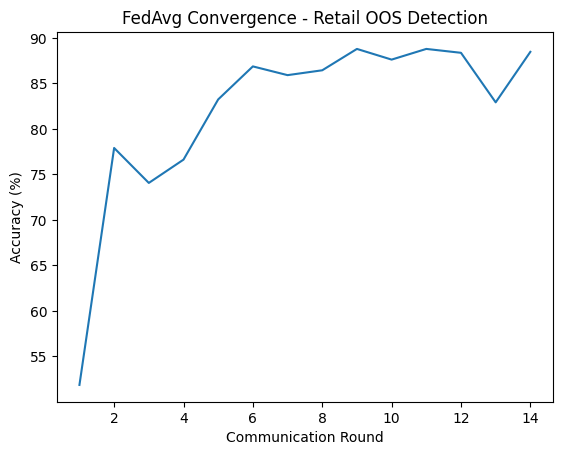

In [ ]:
# ==========================
# A2: Global Accuracy vs. Communication Rounds
# ==========================
plt.plot(range(1, len(fedavg_global_acc_history) + 1), fedavg_global_acc_history)
plt.title("FedAvg Convergence - Retail OOS Detection")
plt.xlabel("Communication Round")
plt.ylabel("Accuracy (%)")
plt.show()

Test Accuracy: 90.88%
Test Loss: 0.23


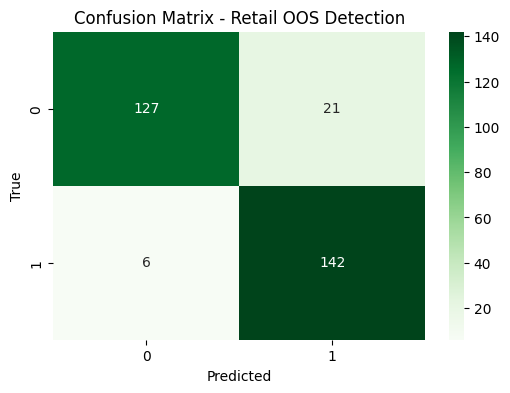

In [ ]:
# ==========================
# Performace of FedAvg Model on Test Set
# ==========================
fedavg_global_model.eval()
test_acc, test_loss = evaluate_model(fedavg_global_model, test_loader)
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.2f}")

# Plot Confusion Matrix
fedavg_global_model.eval() # Ensure model is in evaluation mode
all_y_true = []
all_y_pred = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = fedavg_global_model(batch_x)
        predicted = (outputs > 0.5).float()
        all_y_pred.extend(predicted.cpu().numpy())
        all_y_true.extend(batch_y.cpu().numpy())

plt.figure(figsize=(6, 4))
cm = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Retail OOS Detection")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##<h4><b>Part B: Adaptive Weight Aggregation (FedAWA)</b></h4>

B1. Compute client vectors τ_k^t = θ_k^t − θ_g^t for each client after local training.

B2. Design adaptive aggregation weights based on the alignment between client vectors and the global update direction. Normalize the weights so that their sum equals one and update the global model accordingly.

In [ ]:
# ==========================
# Flattening Model Parameters
# ==========================
def get_flattened_params(model):
  """
  Converts model parameters into a single 1D vector.
  """
  return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flattened_params(model, flat_params):
  """
  Restores a 1D vector back into the model's layers.
  """
  idx = 0
  for p in model.parameters():
    numel = p.data.numel()
    p.data.copy_(flat_params[idx:idx + numel].view_as(p.data))
    idx += numel

In [ ]:
# ==========================
# FEDERATED TRAINING LOOP
# B1: ADAPTIVE WEIGHT AGGREGATION
# ==========================
def run_fedawa(global_model, client_loaders, test_loader=val_loader, rounds=NUM_ROUNDS):
  acc_history = []
  loss_history = []
  best_acc = 0.0
  # Initialize EarlyStopping
  early_stopping = EarlyStopping(patience=5, verbose=True)

  for r in range(rounds):
    t_vectors = []
    global_flat = get_flattened_params(global_model)

    for i in range(NUM_CLIENTS):
      local_model = copy.deepcopy(global_model)
      local_train(local_model, client_loaders[i])

      # B1: Compute client vector t_k = theta_local - theta_global
      local_flat = get_flattened_params(local_model)
      t_k = local_flat - global_flat
      t_vectors.append(t_k)

    # B2: Adaptive Weighting
    t_avg = torch.stack(t_vectors).mean(dim=0)  # Consensus direction

    similarities = []
    for t_k in t_vectors:
      # Cosine similarity between client update and average update
      cos_sim = F.cosine_similarity(t_k.unsqueeze(0), t_avg.unsqueeze(0))
      similarities.append(torch.clamp(cos_sim, min=1e-5))

    # Normalize weights so sum = 1
    weights = torch.tensor(similarities) / torch.sum(torch.tensor(similarities))

    # Update global model using adaptive weights
    new_global_flat = global_flat + torch.stack([t_vectors[i] * weights[i] for i in range(NUM_CLIENTS)]).sum(dim=0)
    # Restore the global model parameters with the new global model parameters
    set_flattened_params(global_model, new_global_flat)

    acc, loss = evaluate_model(global_model, test_loader)
    acc_history.append(acc)
    loss_history.append(loss)
    print(f"\n--- Communication Round {r + 1}/{NUM_ROUNDS} ---")
    print(f"Global Accuracy: {acc:.2f}% | Loss: {loss:.2f}")

    # Save the best global model so far...
    if acc > best_acc:
      best_acc = acc
      torch.save(global_model.state_dict(), 'fedawa_best_model.pth')
      print(f"New best model saved with accuracy {best_acc:.2f}%")

    # Apply EarlyStopping to Global Model
    if r > 0:
      early_stopping(loss, global_model)
      if early_stopping.early_stop:
        print("Early stopping triggered.")
        break
  # Save the best model
  global_model.load_state_dict(torch.load('fedawa_best_model.pth'))
  return global_model, acc_history, loss_history

# Run FedAWA Logic
# global_model = CNN() # Reset global model
print(f"=== Accuracy History of FedAWA ===")
fedawa_global_model, fedawa_global_acc_history, fedawa_global_loss_history = run_fedawa(CNN(), client_loaders)

=== Accuracy History of FedAWA ===

--- Communication Round 1/30 ---
Global Accuracy: 48.56% | Loss: 1.48
New best model saved with accuracy 48.56%

--- Communication Round 2/30 ---
Global Accuracy: 51.44% | Loss: 0.68
New best model saved with accuracy 51.44%
Validation loss decreased (inf --> 0.682670).  Saving model ...

--- Communication Round 3/30 ---
Global Accuracy: 49.20% | Loss: 4.32
EarlyStopping counter: 1 out of 5

--- Communication Round 4/30 ---
Global Accuracy: 67.77% | Loss: 0.63
New best model saved with accuracy 67.77%
Validation loss decreased (0.682670 --> 0.631099).  Saving model ...

--- Communication Round 5/30 ---
Global Accuracy: 67.88% | Loss: 0.62
New best model saved with accuracy 67.88%
Validation loss decreased (0.631099 --> 0.617523).  Saving model ...

--- Communication Round 6/30 ---
Global Accuracy: 84.63% | Loss: 0.47
New best model saved with accuracy 84.63%
Validation loss decreased (0.617523 --> 0.470337).  Saving model ...

--- Communication Round

Test Accuracy: 93.58%
Test Loss: 0.20


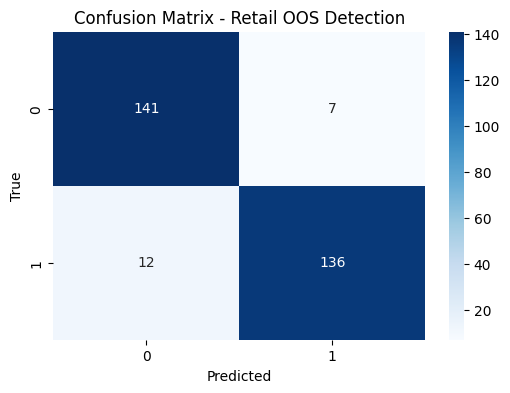

In [ ]:
# ==========================
# Performace of FedAWA Model on Test Set
# ==========================
fedawa_global_model.eval()
test_acc, test_loss = evaluate_model(fedawa_global_model, test_loader)
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.2f}")

# Plot Confusion Matrix
fedavg_global_model.eval() # Ensure model is in evaluation mode
all_y_true = []
all_y_pred = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = fedawa_global_model(batch_x)
        predicted = (outputs > 0.5).float()
        all_y_pred.extend(predicted.cpu().numpy())
        all_y_true.extend(batch_y.cpu().numpy())

plt.figure(figsize=(6, 4))
cm = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Retail OOS Detection")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##<h4><b> Part C: Compare FedAvg and FedAWA </b></h4>

In terms of convergence speed and final accuracy.

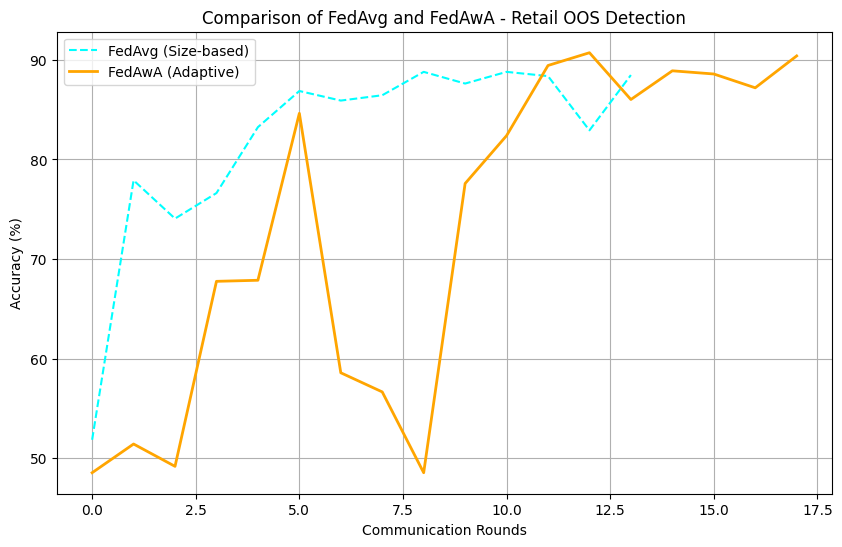

In [ ]:
# ==========================
# Compare FedAvg and FedAWA
# ==========================
plt.figure(figsize=(10,6))
plt.plot(fedavg_global_acc_history, label='FedAvg (Size-based)', color='cyan', linestyle='--')
plt.plot(fedawa_global_acc_history, label='FedAwA (Adaptive)', color='orange', linewidth=2)
plt.title("Comparison of FedAvg and FedAwA - Retail OOS Detection")
plt.xlabel("Communication Rounds")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

## <h4><b>Comparison</b></h4>
<b>1. FedAvg (The Baseline)</b>


*   <b>How it works:</b> It averages client models based solely on their sample size.
*   <b>The Weakness:</b> It assumes all clients are moving toward a similar goal. If one client has "noisy" data or labels that contradict other clients, FedAvg still gives them a high weight just because they have a lot of data. This "drags" the global model away from the optimal point, causing the accuracy drops you saw in your logs.
*   <b>Best for:</b> IID data (where everyone’s data looks the same).


<b>2. FedAWA (The Optimizer)</b>


*   <b>How it works:</b> It uses Adaptive Weight Aggregation. It looks at the direction of the client updates (using Cosine Similarity).
*   <b>The Strength:</b> If a client’s update aligns well with the "consensus" (the average direction), FedAWA gives it more weight. If a client's update is pointing in a strange, contradictory direction, FedAWA automatically reduces its influence.
*   <b>Best for:</b> Non-IID data and noisy environments. It is much more "stable" because it actively filters out harmful updates.





